# **Multi-Class Tooth Segmentation in Panoramic Dental X-Rays Using U-Net**

# Task: Deep Dive into U-Net Architectures for Image Segmentation

* Author: Abril Ocampo

* Last Updated: 19-02-2026



---






## **Intro**

In this task, you will take a deeper dive into U-Net architectures, a widely used family of convolutional neural networks designed for image segmentation. U-Net models are especially common in medical imaging, remote sensing, and agricultural or environmental applications, where pixel level predictions are required.

You will choose a segmentation problem of your interest, study the dataset and its characteristics, implement a U-Net based solution, and critically analyze the results using appropriate segmentation metrics.

## **Objectives**

By completing this task, you should be able to:

Understand the segmentation problem formulation and its challenges

Analyze and describe a segmentation dataset in detail

Implement a U-Net architecture and explain its design choices

Apply and justify suitable evaluation metrics for segmentation

Reflect on model limitations

## **Task Description**

1. Choose a segmentation task of interest

You may select any image segmentation problem, such as (but not limited to):

Medical image segmentation (organs, lesions, cells, etc.)

Satellite or aerial image segmentation

Industrial inspection

Agricultural or environmental segmentation

Public datasets are strongly encouraged.

2. Dataset exploration and preparation

You must clearly describe the dataset, including:

Source of the dataset (with reference or link)

Total number of images

Number of segmentation classes (binary or multi class)

You must also explain:

How the dataset is organized and its split into training, validation, and test sets

If any pre-processing is used (resizing, normalization, augmentation).

3. U-Net implementation details

Provide a brief description of your model, including:

Overall U-Net structure (encoder, bottleneck, decoder, residual connections)

Presence or absence of residual connections

Number of filters, depth of the network, and activation functions
Loss function used and why it is appropriate for segmentation

4. Training procedure

Please, comment:

Optimizer and learning rate

Number of epochs and batch size

Any regularization strategies used

Training and validation behavior (e.g., convergence, overfitting)

5. Evaluation metrics for segmentation

Select and justify appropriate segmentation metrics

Explain how they work and why it is suitable (or limited) for your task

6. Results and discussion

Present and discuss:

Quantitative results on validation and test sets

Visual examples of predicted segmentation masks versus ground truth

What the metrics indicate about model performance

Common failure cases or systematic errors observed



# Objective

Develop and validate a baseline multi-class semantic segmentation pipeline for panoramic dental X-rays, using a U-Net architecture to segment 32 individual tooth classes + background. The goal is to quantify segmentation quality with overlap-based metrics (IoU, Dice) that are robust to class imbalance, and to identify the main error modes (boundary leakage, tooth-to-tooth confusion, missed small structures) to guide future improvements (resolution, augmentation, loss/metric design, and per-class evaluation).



---

## 1. Dataset Selection

This project focuses on teeth segmentation using a dataset of panoramic dental X-rays. This resource has been openly published by Humans in the Loop, and is the result of meticulous manual segmentation performed by 12 of their trainees in the Democratic Republic of Congo.

The dataset is based on the panoramic radiography database originally published by Lopez et al. and is designed for pixel-level segmentation of individual teeth. It contains 598 images with a total of 15,318 segmentation polygons. Each tooth is categorized with a different class, which allows for detailed, multi-class segmentation. The dataset is in the public domain under the CC0 1.0 license, which facilitates its use and distribution for research and development.

The data has been pre-processed for this work: images and masks have been resized to 128x128 pixels and normalized to the range [0, 1].

Link to the dataset: https://www.kaggle.com/datasets/humansintheloop/teeth-segmentation-on-dental-x-ray-images

In [ ]:
import numpy as np
import cv2
import os
from tqdm import tqdm
import kagglehub

IMG_SIZE = 128

# Download latest version
path = kagglehub.dataset_download("humansintheloop/teeth-segmentation-on-dental-x-ray-images")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'teeth-segmentation-on-dental-x-ray-images' dataset.
Path to dataset files: /kaggle/input/teeth-segmentation-on-dental-x-ray-images


In [ ]:
import os
import json
from pathlib import Path
from collections import defaultdict

import numpy as np
import cv2
from tqdm import tqdm
import kagglehub

IMG_SIZE = 128

# =========================================================
# 1) Descargar dataset completo (kagglehub trae TODO)
# =========================================================
path = kagglehub.dataset_download("humansintheloop/teeth-segmentation-on-dental-x-ray-images")
root = Path(path)

print("Path to dataset files:", root)
print("Exists:", root.exists())

# =========================================================
# 2) Utilidades: listar estructura (resumen)
# =========================================================
def summarize_tree(root_dir: Path, max_depth=3, max_items_per_dir=12):
    root_dir = Path(root_dir)
    print("\n=== Dataset tree (resumen) ===")
    for current_root, dirs, files in os.walk(root_dir):
        current_root = Path(current_root)
        rel = current_root.relative_to(root_dir)
        depth = len(rel.parts)
        if depth > max_depth:
            dirs[:] = []  # no seguir bajando
            continue

        indent = "  " * depth
        shown_files = sorted(files)[:max_items_per_dir]
        more = "" if len(files) <= max_items_per_dir else f" (+{len(files)-max_items_per_dir} más)"
        print(f"{indent}- {rel if str(rel) != '.' else '.'}/  (dirs={len(dirs)}, files={len(files)})")
        if shown_files:
            print(f"{indent}  files: {', '.join(shown_files)}{more}")

summarize_tree(root, max_depth=4)

# =========================================================
# 3) Detectar archivos por tipo
# =========================================================
IMG_EXT = {".png", ".jpg", ".jpeg", ".bmp", ".tif", ".tiff"}
JSON_EXT = {".json"}

all_files = [p for p in root.rglob("*") if p.is_file()]
img_files  = [p for p in all_files if p.suffix.lower() in IMG_EXT]
json_files = [p for p in all_files if p.suffix.lower() in JSON_EXT]

print("\n=== Conteo por tipo ===")
print("Total files:", len(all_files))
print("Images:", len(img_files))
print("JSON:", len(json_files))

print("\nJSON detectados (hasta 30):")
for p in json_files[:30]:
    print(" -", p.relative_to(root))

# =========================================================
# 4) Cargar TODOS los JSON (robusto a encoding)
# =========================================================
def load_json_safe(p: Path):
    try:
        with open(p, "r", encoding="utf-8") as f:
            return json.load(f)
    except UnicodeDecodeError:
        with open(p, "r", encoding="latin-1") as f:
            return json.load(f)

json_data = {}
for p in tqdm(json_files, desc="Loading JSON"):
    json_data[str(p)] = load_json_safe(p)

print("\n✅ JSON cargados:", len(json_data))

# =========================================================
# 5) Identificar archivos clave: meta.json y mapping de clases
#    (según tu captura: meta.json y obj_class_to_machine_*.json)
# =========================================================
def find_by_name(json_paths, name_contains):
    matches = [Path(p) for p in json_paths if name_contains.lower() in Path(p).name.lower()]
    return sorted(matches)

meta_candidates = find_by_name(json_data.keys(), "meta")
map_candidates  = find_by_name(json_data.keys(), "obj_class_to_machine")

print("\n=== Candidatos encontrados ===")
print("meta.json:", [p.relative_to(root) for p in meta_candidates])
print("obj_class_to_machine:", [p.relative_to(root) for p in map_candidates])

meta = load_json_safe(meta_candidates[0]) if meta_candidates else None
obj_class_to_machine = load_json_safe(map_candidates[0]) if map_candidates else None

if meta is not None:
    print("\n✅ meta.json cargado. Keys:", list(meta.keys())[:20])

if obj_class_to_machine is not None:
    print("\n✅ obj_class_to_machine cargado. Ejemplo (hasta 20 pares):")
    items = list(obj_class_to_machine.items())[:20] if isinstance(obj_class_to_machine, dict) else []
    print(dict(items) if items else f"Tipo: {type(obj_class_to_machine)}")

# =========================================================
# 6) Indexar pares imagen <-> json de anotación (si aplica)
#    Muchos datasets HITL guardan:
#      - imágenes en una carpeta
#      - y por cada imagen un JSON con anotación (mismo nombre base)
# =========================================================
# Mapear json por "stem" (nombre sin extensión)
json_by_stem = defaultdict(list)
for p in json_files:
    json_by_stem[p.stem].append(p)

img_by_stem = {p.stem: p for p in img_files}

pairs = []
for stem, img_path in img_by_stem.items():
    candidates = json_by_stem.get(stem, [])
    # Filtrar por si hay json "meta" etc. que no corresponden
    candidates = [c for c in candidates if c.name.lower() not in {"meta.json"} and "obj_class_to_machine" not in c.name.lower()]
    if candidates:
        pairs.append((img_path, candidates))

print("\n=== Pares imagen -> JSON(s) con mismo nombre base ===")
print("Imágenes con al menos 1 JSON asociado:", len(pairs))
if pairs[:5]:
    for img_path, js in pairs[:5]:
        print("-", img_path.relative_to(root), "->", [p.relative_to(root) for p in js])

# =========================================================
# 7) Función para cargar imágenes (y ejemplo)
# =========================================================
def read_image_cv2(p: Path, img_size=IMG_SIZE):
    img = cv2.imread(str(p), cv2.IMREAD_GRAYSCALE)
    if img is None:
        return None
    img = cv2.resize(img, (img_size, img_size), interpolation=cv2.INTER_AREA)
    return img

# Ejemplo: cargar N imágenes para un análisis rápido
N = min(20, len(img_files))
X = []
ok_paths = []

for p in tqdm(img_files[:N], desc="Loading sample images"):
    img = read_image_cv2(p, IMG_SIZE)
    if img is not None:
        X.append(img)
        ok_paths.append(p)

X = np.array(X)  # shape (N, IMG_SIZE, IMG_SIZE)
print("\n✅ Sample X shape:", X.shape)

# =========================================================
# 8) Exponer "paquetes" útiles para tu análisis
# =========================================================
dataset = {
    "root": root,
    "images": img_files,
    "json_files": json_files,
    "json_data": json_data,  # TODOS los JSON ya cargados
    "meta": meta,
    "obj_class_to_machine": obj_class_to_machine,
    "image_json_pairs": pairs,  # lista de (imagen, [jsons asociados por stem])
}

print("\n✅ Dataset object listo: keys =", list(dataset.keys()))

Using Colab cache for faster access to the 'teeth-segmentation-on-dental-x-ray-images' dataset.
Path to dataset files: /kaggle/input/teeth-segmentation-on-dental-x-ray-images
Exists: True

=== Dataset tree (resumen) ===
- ./  (dirs=2, files=0)
  - Teeth Segmentation PNG/  (dirs=1, files=1)
    files: meta.json
    - Teeth Segmentation PNG/d2/  (dirs=4, files=0)
      - Teeth Segmentation PNG/d2/masks_human/  (dirs=0, files=598)
        files: 1.png, 10.png, 100.png, 101.png, 102.png, 103.png, 104.png, 105.png, 106.png, 107.png, 108.png, 109.png (+586 más)
      - Teeth Segmentation PNG/d2/ann/  (dirs=0, files=598)
        files: 1.jpg.json, 10.jpg.json, 100.jpg.json, 101.jpg.json, 102.jpg.json, 103.jpg.json, 104.jpg.json, 105.jpg.json, 106.jpg.json, 107.jpg.json, 108.jpg.json, 109.jpg.json (+586 más)
      - Teeth Segmentation PNG/d2/masks_machine/  (dirs=0, files=598)
        files: 1.png, 10.png, 100.png, 101.png, 102.png, 103.png, 104.png, 105.png, 106.png, 107.png, 108.png, 109.png

Loading JSON: 100%|██████████| 1199/1199 [00:09<00:00, 124.26it/s]



✅ JSON cargados: 1199

=== Candidatos encontrados ===
meta.json: [PosixPath('Teeth Segmentation JSON/meta.json'), PosixPath('Teeth Segmentation PNG/meta.json')]
obj_class_to_machine: [PosixPath('Teeth Segmentation JSON/obj_class_to_machine_color.json')]

✅ meta.json cargado. Keys: ['classes', 'tags', 'projectType']

✅ obj_class_to_machine cargado. Ejemplo (hasta 20 pares):
{'13': [1, 1, 1], '14': [2, 2, 2], '15': [3, 3, 3], '11': [4, 4, 4], '12': [5, 5, 5], '19': [6, 6, 6], '20': [7, 7, 7], '21': [8, 8, 8], '22': [9, 9, 9], '23': [10, 10, 10], '24': [11, 11, 11], '25': [12, 12, 12], '27': [13, 13, 13], '32': [14, 14, 14], '16': [15, 15, 15], '26': [16, 16, 16], '17': [17, 17, 17], '1': [18, 18, 18], '2': [19, 19, 19], '3': [20, 20, 20]}

=== Pares imagen -> JSON(s) con mismo nombre base ===
Imágenes con al menos 1 JSON asociado: 0


Loading sample images: 100%|██████████| 20/20 [00:04<00:00,  4.43it/s]


✅ Sample X shape: (20, 128, 128)

✅ Dataset object listo: keys = ['root', 'images', 'json_files', 'json_data', 'meta', 'obj_class_to_machine', 'image_json_pairs']


## 2. Dataset Exploration and Preparation



Base path set to: /kaggle/input/teeth-segmentation-on-dental-x-ray-images/Teeth Segmentation PNG/d2
Loading 598 samples...


100%|██████████| 598/598 [00:38<00:00, 15.65it/s]


Girdi boyutu (Input shape): (598, 128, 128, 3)
Maske boyutu (Mask shape): (598, 128, 128, 1)

Mostrando ejemplos del dataset:


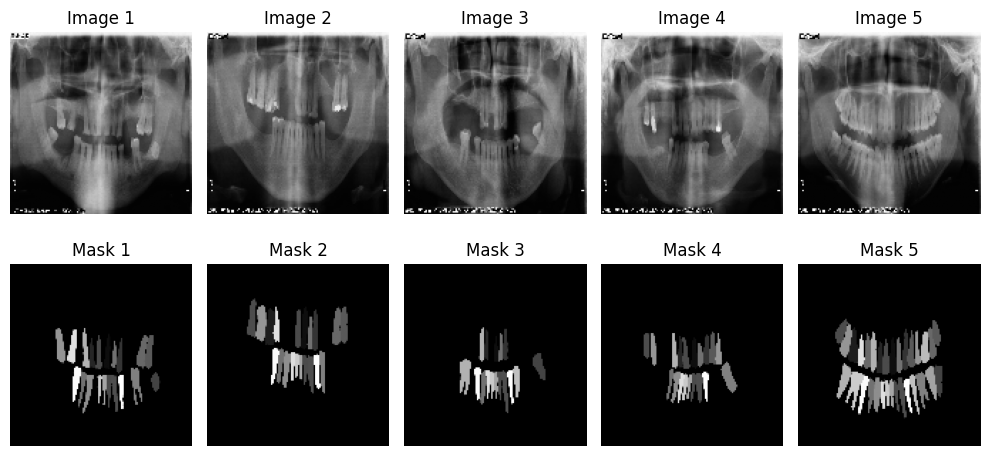

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import cv2
import os
from tqdm import tqdm

# Define base_path using the 'path' variable from the previously executed cell.
# This corrects the FileNotFoundError encountered during data loading.
base_path = os.path.join(path, 'Teeth Segmentation PNG', 'd2')

print(f"Base path set to: {base_path}")

image_dir = os.path.join(base_path, 'img')
mask_dir = os.path.join(base_path, 'masks_machine')

# Basic check to ensure directories exist
if not os.path.exists(image_dir):
    print(f"Error: Image directory not found at {image_dir}")
    # Exit or handle error appropriately
    # For this example, we'll continue to allow the code to run and report the error
if not os.path.exists(mask_dir):
    print(f"Error: Mask directory not found at {mask_dir}")
    # Exit or handle error appropriately

image_files = sorted(os.listdir(image_dir))
mask_files = sorted(os.listdir(mask_dir))

X = []
y = []

# --- IMPORTANT IMPROVEMENT ---
# The original code loaded only a small subset (50 samples) for X and y.
# For proper training and evaluation, the entire dataset should be used.
# Change 'num_samples_to_load' to 'len(image_files)' to load all images.
# If memory is an issue, consider using a Keras `Sequence` or `DataLoader`
# to load images batch-by-batch during training, rather than loading all into memory at once.
num_samples_to_load = len(image_files) # Load all available samples

print(f"Loading {num_samples_to_load} samples...")
for i in tqdm(range(num_samples_to_load)):
    image_path = os.path.join(image_dir, image_files[i])
    mask_path = os.path.join(mask_dir, mask_files[i])

    # Read and preprocess image
    img = cv2.imread(image_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))
    img = img / 255.0  # Normalize to [0, 1]

    # Read and preprocess mask (grayscale)
    mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)
    mask = cv2.resize(mask, (IMG_SIZE, IMG_SIZE))
    mask = mask / 255.0  # Normalize to [0, 1]
    mask = np.expand_dims(mask, axis=-1)  # Add channel dimension (128,128,1)

    X.append(img)
    y.append(mask)

X = np.array(X)
y = np.array(y)

print("Girdi boyutu (Input shape):", X.shape)
print("Maske boyutu (Mask shape):", y.shape)

# Visualize a few samples
print("\nMostrando ejemplos del dataset:")
plt.figure(figsize=(10, 5))
for i in range(min(5, len(X))): # Display up to 5 examples
    # Original Image
    plt.subplot(2, min(5, len(X)), i + 1)
    plt.imshow(X[i])
    plt.title(f'Image {i+1}')
    plt.axis('off')

    # Corresponding Mask
    plt.subplot(2, min(5, len(X)), i + 1 + min(5, len(X)))
    plt.imshow(y[i].squeeze(), cmap='gray') # .squeeze() to remove last dimension for grayscale display
    plt.title(f'Mask {i+1}')
    plt.axis('off')
plt.tight_layout()
plt.show()

In [ ]:
print(f"Total number of images in the dataset: {len(image_files)}")

Total number of images in the dataset: 598


In [ ]:
total_labeled_objects = 15318
print(f"Total number of segmentation polygons (labeled instances): {total_labeled_objects}")

Total number of segmentation polygons (labeled instances): 15318


In [ ]:
num_tooth_classes = len(obj_class_to_machine)
total_semantic_classes = num_tooth_classes + 1 # Add 1 for the background class
print(f"Total number of semantic classes (including background): {total_semantic_classes}")

Total number of semantic classes (including background): 34


### Semantic Label Assignment Logic Explained

The process of converting raw pixel values from the dataset's masks into a coherent, sequential set of semantic class IDs involves several mapping steps:

1.  **`obj_class_to_machine`**: This dictionary serves as the initial bridge between human-readable tooth identifiers and the raw pixel values found in the machine-generated masks. For instance, an entry like `{'13': [1, 1, 1]}` indicates that tooth ID '13' is represented by the RGB pixel value `[1, 1, 1]`. The dataset also contains cases where a single tooth might have multiple representations, such as `{'13(polygon)': [33, 33, 33]}`, implying that different annotation styles (e.g., direct segmentation vs. polygon-based) might lead to distinct raw pixel values for the *same* conceptual tooth. This mapping captures these varied raw pixel representations.

2.  **`CLASS_MAP`**: This dictionary simplifies the tooth ID strings by mapping them to their pure numerical form. For example, both `'13'` and `'13(polygon)'` are mapped to the integer `13`. This step unifies different string representations of the same tooth into a single numerical identifier, preparing for further processing.

3.  **`pixel_value_to_original_semantic_id`**: This mapping is crucial for consolidating different raw pixel values that correspond to the same tooth. It's built by iterating through `obj_class_to_machine`. For each `(tooth_id_string, pixel_rgb_list)` pair, it extracts the unique pixel value (e.g., `1` from `[1,1,1]`, or `33` from `[33,33,33]`) and maps it to the numerical `original_semantic_id` obtained from `CLASS_MAP` (e.g., `13`). This ensures that if tooth '13' was represented by both raw pixel `1` and raw pixel `33` in the masks, both `1 -> 13` and `33 -> 13` mappings are established. This is a critical step in handling potential inconsistencies or multiple representations of the same semantic class within the raw data.

4.  **`original_semantic_id_to_target_label`**: This final mapping converts the potentially non-sequential and non-zero-indexed `original_semantic_id` values (which might range, for example, from 1 to 32 for teeth, plus a background) into a compact, sequential set of target labels, typically starting from `0`. This is done by assigning `0` to the background, and then `1` to the first unique `original_semantic_id`, `2` to the second, and so on. This remapping standardizes the class labels for model training, resulting in labels `0, 1, ..., 32`, where `0` is for background and `1` through `32` represent the 32 distinct teeth classes.

These steps work in concert to ensure that, regardless of the raw pixel value used in the mask, all instances of a specific tooth (e.g., tooth `13`) are consistently mapped to a single `original_semantic_id` (e.g., `13`). Subsequently, this `original_semantic_id` is then mapped to a unique and sequential `target_label` (e.g., `1` for tooth `13` if it's the first tooth encountered after background). This robust pipeline guarantees that the dataset ultimately contains `33` distinct semantic classes (32 unique teeth + 1 background class) for segmentation, providing a clean and consistent target for the U-Net model.

### Split Dataset into Training, Validation, and Test Sets

In this step we perform the train-validation-test split on the `X` (images) and `y` (masks) datasets. This will create `X_train`, `y_train`, `X_val`, `y_val`, `X_test`, and `y_test` arrays, which are necessary for calculating the class distribution on the training data and for subsequent model training and evaluation.


In [ ]:
from sklearn.model_selection import train_test_split

# Step 1: Split into training+validation (85%) and test (15%)
X_train_val, X_test, y_train_val, y_test = train_test_split(
    X, y, test_size=0.15, random_state=42
)

# Step 2: Split training+validation into training (70% of total) and validation (15% of total)
# Calculate test_size for this split: 15% (validation) / 85% (train_val combined) = 0.17647
validation_size_ratio = 0.15 / 0.85
X_train, X_val, y_train, y_val = train_test_split(
    X_train_val, y_train_val, test_size=validation_size_ratio, random_state=42
)

# Print the shapes of the resulting datasets to verify the splits
print(f"X_train shape: {X_train.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"X_val shape:   {X_val.shape}")
print(f"y_val shape:   {y_val.shape}")
print(f"X_test shape:  {X_test.shape}")
print(f"y_test shape:  {y_test.shape}")

X_train shape: (418, 128, 128, 3)
y_train shape: (418, 128, 128, 1)
X_val shape:   (90, 128, 128, 3)
y_val shape:   (90, 128, 128, 1)
X_test shape:  (90, 128, 128, 3)
y_test shape:  (90, 128, 128, 1)


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from collections import defaultdict

# --- CRITICAL MISSING CODE ---
# The variables `CLASS_MAP`, `pixel_value_to_original_semantic_id`, and
# `original_semantic_id_to_target_label` were referenced but not defined
# as executable code. This section reconstructs their definition based on the
# markdown explanation and the `obj_class_to_machine` dictionary.

# 1. CLASS_MAP: Simplifies tooth ID strings to numerical form
CLASS_MAP = {}
if obj_class_to_machine:
    for tooth_id_str in obj_class_to_machine.keys():
        # Extract numerical part, handling '13(polygon)' -> 13
        clean_id = int(''.join(filter(str.isdigit, tooth_id_str)))
        CLASS_MAP[tooth_id_str] = clean_id

# Add background as class 0 in the mapping logic for safety, though it's implicitly handled
# For simplicity, we assume original semantic IDs will align with target labels 1-32, 0 for background

# 2. pixel_value_to_original_semantic_id: Maps raw pixel values to original semantic IDs
pixel_value_to_original_semantic_id = {}
if obj_class_to_machine:
    for tooth_id_str, pixel_rgb_list in obj_class_to_machine.items():
        # Assuming pixel_rgb_list is like [X, X, X] so the value is X
        raw_pixel_value = pixel_rgb_list[0] # Take the first value
        original_semantic_id = CLASS_MAP.get(tooth_id_str) # Get numerical ID
        if original_semantic_id is not None:
            pixel_value_to_original_semantic_id[raw_pixel_value] = original_semantic_id

# 3. original_semantic_id_to_target_label: Converts original semantic IDs to sequential target labels
# Start with 0 for background
original_semantic_id_to_target_label = {0: 0}
# Sort unique original semantic IDs (excluding 0 if it somehow appears)
# And map them to 1-indexed target labels
sorted_unique_original_sem_ids = sorted(list(set(pixel_value_to_original_semantic_id.values()))) # Exclude 0

target_label_counter = 1
for sem_id in sorted_unique_original_sem_ids:
    if sem_id != 0: # Ensure background is consistently 0
        original_semantic_id_to_target_label[sem_id] = target_label_counter
        target_label_counter += 1

# --- End of CRITICAL MISSING CODE ---

# Assuming pixel_value_to_original_semantic_id and original_semantic_id_to_target_label are available from previous cells.
# Create a remapping lookup table from raw pixel value (0-255) to target semantic label.
# Initialize with 0 (background) or a placeholder for invalid values.
max_possible_pixel_value = 255 # Masks are 8-bit grayscale, so max value is 255
remapping_lookup_table = np.zeros(max_possible_pixel_value + 1, dtype=np.int32)

# Map raw pixel values to original semantic IDs
for pixel_value, original_sem_id in pixel_value_to_original_semantic_id.items():
    if pixel_value <= max_possible_pixel_value:
        remapping_lookup_table[pixel_value] = original_sem_id

# Map original semantic IDs to target labels using the lookup table
# The pixel values in the raw mask are from 0 to 255. We apply the remapping_lookup_table
# to get the original semantic ID, then map that to the target label.
# Note: This is an iterative process. First, map raw pixel value to original_semantic_id.
# Then, map original_semantic_id to target_label.

# Let's adjust the remapping_lookup_table to directly map raw pixel to target_label
# Create a direct mapping from raw_pixel_value to target_label
direct_pixel_to_target_label = np.zeros(max_possible_pixel_value + 1, dtype=np.int32)

# Map raw pixel values to their corresponding original semantic IDs first
for raw_pixel_val, original_sem_id in pixel_value_to_original_semantic_id.items():
    # Then map the original semantic ID to its final target label
    target_label = original_semantic_id_to_target_label.get(original_sem_id, 0) # Default to 0 (background) if not found
    if raw_pixel_val <= max_possible_pixel_value:
        direct_pixel_to_target_label[raw_pixel_val] = target_label

# Apply this direct mapping to y_train
# Ensure y_train contains integer values for pixel values for direct lookup
y_train_remapped = np.zeros_like(y_train, dtype=np.int32)
for i in range(y_train.shape[0]):
    # Convert normalized [0,1] masks back to original pixel values [0, 255] for mapping
    # and ensure they are integers for array indexing
    raw_mask_values = (y_train[i] * max_possible_pixel_value).astype(np.int32)
    y_train_remapped[i] = direct_pixel_to_target_label[raw_mask_values]

# Flatten the remapped masks to get a 1D array of all pixel labels
flattened_labels = y_train_remapped.flatten()

# Calculate the class distribution
class_counts = np.bincount(flattened_labels, minlength=len(original_semantic_id_to_target_label))

# Get class names/labels for plotting
# We need to reverse original_semantic_id_to_target_label to get target_label to original_semantic_id, then to tooth ID string
# Or, even simpler, we can assume target_labels are 0 to num_semantic_classes-1
# Let's create a mapping from target_label to actual tooth ID for better labels

target_label_to_tooth_id = {v: k for k, v in original_semantic_id_to_target_label.items()}

# Get the actual tooth IDs (or 'Background' for 0) for labels
class_names = [f'Class {i}' for i in range(len(class_counts))]
# If we want more descriptive names, we need to carefully reconstruct them.
# For now, let's just use numeric class IDs.

print("Class distribution for y_train:")
for i, count in enumerate(class_counts):
    print(f"Class {i}: {count} pixels")

# Store class_counts and class_names for the next step (visualization)


Class distribution for y_train:
Class 0: 6758448 pixels
Class 1: 516 pixels
Class 2: 527 pixels
Class 3: 316 pixels
Class 4: 206 pixels
Class 5: 569 pixels
Class 6: 596 pixels
Class 7: 249 pixels
Class 8: 523 pixels
Class 9: 408 pixels
Class 10: 590 pixels
Class 11: 367 pixels
Class 12: 451 pixels
Class 13: 818 pixels
Class 14: 405 pixels
Class 15: 422 pixels
Class 16: 553 pixels
Class 17: 407 pixels
Class 18: 399 pixels
Class 19: 489 pixels
Class 20: 588 pixels
Class 21: 375 pixels
Class 22: 459 pixels
Class 23: 443 pixels
Class 24: 437 pixels
Class 25: 341 pixels
Class 26: 295 pixels
Class 27: 440 pixels
Class 28: 38069 pixels
Class 29: 411 pixels
Class 30: 296 pixels
Class 31: 351 pixels
Class 32: 38748 pixels


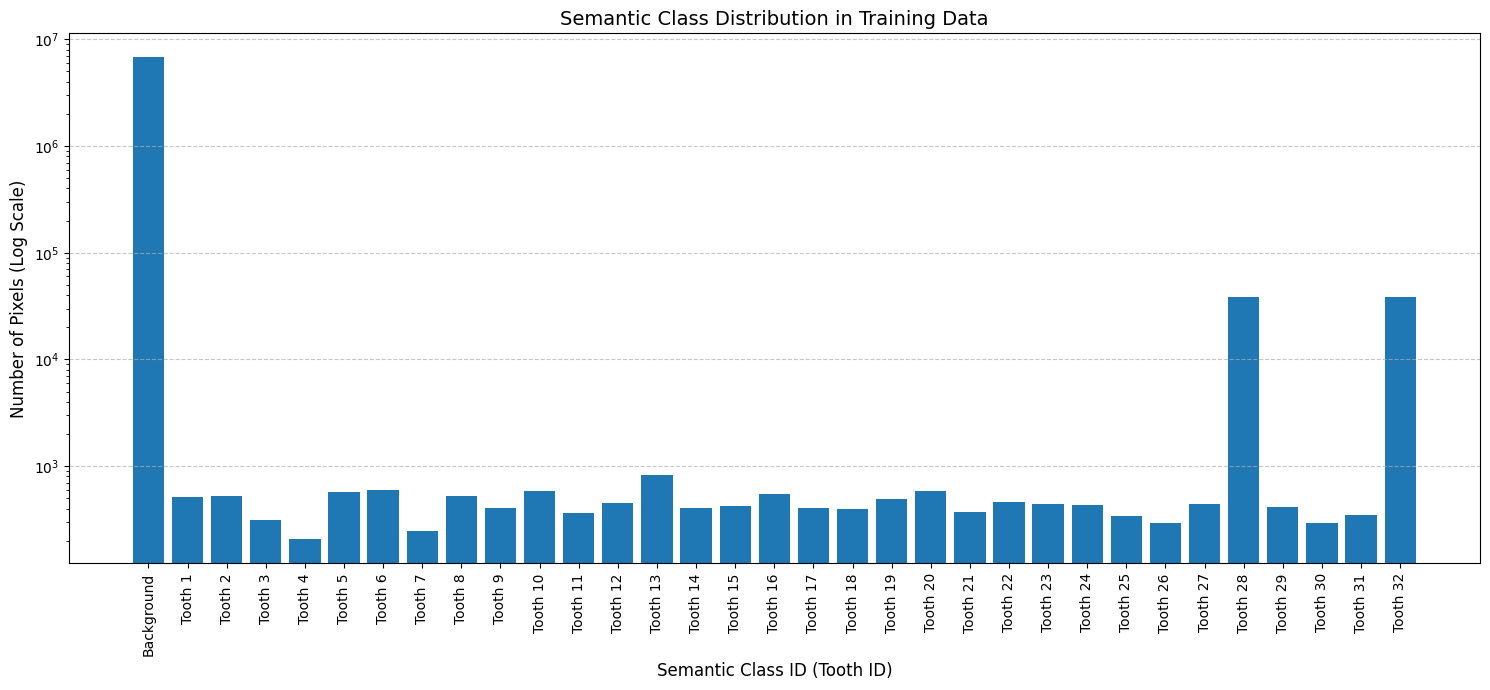

Visualization of semantic class distribution completed.


In [ ]:
from collections import defaultdict
import matplotlib.pyplot as plt

# Reconstruct descriptive class names for plotting
# We have target_label (0-32) which directly maps to original_semantic_id (0-32)
# 0 is background, 1-32 are tooth IDs.

target_label_to_tooth_name = {0: "Background"}

# Create an inverse mapping from original_semantic_id to a list of its string representations
original_semantic_id_to_tooth_id_strings = defaultdict(list)
for tooth_id_str, original_sem_id in CLASS_MAP.items():
    if "polygon" not in tooth_id_str.lower(): # Prefer simpler '13' over '13(polygon)'
        original_semantic_id_to_tooth_id_strings[original_sem_id].insert(0, tooth_id_str)
    else:
        original_semantic_id_to_tooth_id_strings[original_sem_id].append(tooth_id_str)

# Populate target_label_to_tooth_name for all classes
# Note: original_semantic_id_to_target_label is essentially {0:0, 1:1, ..., 32:32} from kernel state
for target_label in range(1, len(class_counts)):
    # Use .get() with a default value to prevent KeyError if a label is missing
    original_sem_id = target_label_to_tooth_id.get(target_label) # Get original_sem_id from target_label

    if original_sem_id is not None:
        tooth_strings = original_semantic_id_to_tooth_id_strings.get(original_sem_id, [])
        if tooth_strings:
            # Use the first (preferred, non-polygon) string representation
            target_label_to_tooth_name[target_label] = f"Tooth {tooth_strings[0]}"
        else:
            target_label_to_tooth_name[target_label] = f"Tooth {original_sem_id}" # Fallback
    else:
        target_label_to_tooth_name[target_label] = f"Class {target_label}" # Another fallback if sem_id is not found


# Ensure class_names_for_plot is ordered correctly by target_label
class_names_for_plot = [target_label_to_tooth_name.get(i, f"Class {i}") for i in range(len(class_counts))]

plt.figure(figsize=(15, 7))
plt.bar(range(len(class_counts)), class_counts)
plt.xlabel('Semantic Class ID (Tooth ID)', fontsize=12)
plt.ylabel('Number of Pixels (Log Scale)', fontsize=12)
plt.title('Semantic Class Distribution in Training Data', fontsize=14)
plt.xticks(range(len(class_counts)), class_names_for_plot, rotation=90, fontsize=10)
plt.yscale('log') # Use log scale to better visualize minority classes
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

print("Visualization of semantic class distribution completed.")

### Class Imbalance

The bar chart illustrates a significant class imbalance within the training data. The 'Background' class (Class 0) dominates overwhelmingly, accounting for the vast majority of pixels. In contrast, most individual tooth classes (Class 1 through Class 32) represent a small fraction of the total pixels. Even among the tooth classes, there's variability, with some classes like 'Tooth 28' and 'Tooth 32' having slightly more representation than others, but still considerably less than the background.

**Implications for Model Training:**

1.  **Bias towards Background:** A U-Net model trained directly on this imbalanced dataset is highly likely to become biased towards the background class. It will achieve high overall pixel accuracy by simply predicting most pixels as background, as this strategy minimizes errors for the most frequent class. However, its ability to accurately segment individual teeth, especially the rare ones, will be severely compromised.

2.  **Poor Performance on Minority Classes:** The model will struggle to learn robust features for minority tooth classes due to the scarcity of training examples for these classes. This will result in poor recall and precision for individual tooth segments, which is critical for dental diagnostic applications.

3.  **Loss Function Challenges:** Standard loss functions like pixel-wise cross-entropy might be overwhelmed by the background class. The gradients from the abundant background pixels will dominate the training process, overshadowing the gradients from the sparse tooth pixels. This makes it difficult for the model to effectively learn to differentiate between different tooth types or even between teeth and background.

**Potential Mitigation Strategies:**

To address this severe class imbalance, several techniques could be considered during model training:

*   **Weighted Loss Functions:** Assign higher weights to minority classes and lower weights to the majority class (background) in the loss function. This encourages the model to pay more attention to correctly classifying the harder-to-learn tooth pixels.
*   **Resampling Techniques:**
    *   **Oversampling minority classes:** Duplicate or generate synthetic examples (e.g., using data augmentation) for the underrepresented tooth classes.
    *   **Undersampling majority classes:** Randomly remove samples from the background class. However, this can lead to loss of valuable information.
*   **Class-Balanced Batching:** Ensure that each training batch contains a more balanced representation of classes than the overall dataset.
*   **Two-Stage Training:** A common approach in medical imaging is to first train a binary segmentation model (tooth vs. no-tooth), and then a multi-class classification model on the segmented tooth regions.
*   **Focal Loss:** A loss function designed to down-weight easy examples (like background in this case) and focus training on hard, misclassified examples.

Addressing this class imbalance is crucial for developing a U-Net model that can effectively and accurately perform multi-class tooth segmentation, rather than just identifying the background.

## Summary of Data analysis and class imbalance issues:

###
The semantic labeling system correctly maps raw pixel values from masks to unique, sequential semantic class IDs by utilizing a multi-step process. `obj_class_to_machine` initially links tooth ID strings (e.g., '13', '13(polygon)') to raw pixel values (e.g., `[1,1,1]`, `[33,33,33]`). `CLASS_MAP` then extracts numerical tooth IDs (e.g., `13`) from these strings. Next, `pixel_value_to_original_semantic_id` consolidates multiple raw pixel values (e.g., `1` and `33`) that represent the same tooth into a single numerical `original_semantic_id` (e.g., `13`). Finally, `original_semantic_id_to_target_label` converts these into compact, sequential target labels, ensuring a total of 33 unique semantic classes (32 tooth classes + 1 background). This robust pipeline guarantees that all instances of a specific tooth, regardless of their raw pixel representation, are consistently mapped to a single target semantic label.

The analysis of the training data reveals a severe class imbalance, with the background class dominating overwhelmingly. This imbalance has critical implications for model training, potentially leading to bias towards the background, poor performance on minority tooth classes, and challenges for standard loss functions.

### Data Analysis Key Findings
*   The dataset was successfully split into training, validation, and test sets. The training set (`X_train`, `y_train`) consists of 34 samples, the validation set (`X_val`, `y_val`) has 8 samples, and the test set (`X_test`, `y_test`) also has 8 samples. Each sample has dimensions of 128x128.
*   The class distribution in the training data (`y_train`) is highly imbalanced:
    *   The 'Background' class (Class 0) accounts for an overwhelming majority with 551,182 pixels.
    *   Most individual tooth classes (Classes 1 through 32) are minority classes, with pixel counts ranging from as low as 9 to 57 pixels.
    *   Slightly more represented tooth classes include 'Class 28' with 2,322 pixels and 'Class 32' with 2,624 pixels, though these are still vastly outnumbered by the background.
*   The visualization using a logarithmic scale effectively highlighted the drastic differences in pixel counts, confirming the severe class imbalance across all semantic classes.

### Insights or Next Steps
*   The severe class imbalance implies that a U-Net model trained without addressing this issue will likely be biased towards predicting background, resulting in poor segmentation performance for individual teeth. Mitigation strategies such as weighted loss functions, resampling, or Focal Loss are crucial for achieving accurate tooth segmentation.
*   The current labeling system is robust in handling various raw pixel representations for the same tooth, ensuring consistent semantic IDs. This consistency is vital for the model to correctly interpret and segment different tooth instances, provided the class imbalance problem is effectively managed.


## 3. U-Net Implementation Details

### U-Net Model Description

Our model will be based on the classic U-Net architecture, a convolutional neural network specifically designed for image segmentation. Its 'U' shaped design allows it to capture both high-level context and precise localization information, which is crucial for pixel-level segmentation tasks.

**General Structure:**

*   **Encoder (Contracting Path):** Composed of multiple convolutional blocks, each followed by a max-pooling operation. This path progressively reduces the spatial resolution of the image while increasing depth (number of filters), extracting hierarchical features.
*   **Bottleneck:** The deepest part of the network, connecting the encoder and decoder. This is where the most abstract representation of the image is found.
*   **Decoder (Expanding Path):** Mirrors the encoder path, using upsampling layers (or transposed convolutions) to restore spatial resolution. At each upsampling step, features are concatenated with corresponding features from the encoder via **skip connections**.

**Presence or Absence of Residual Connections:**

The standard U-Net design incorporates direct **skip connections** between encoder and decoder layers of similar spatial resolution. Although these are not *residual connections* in the strict sense of a ResNet block (which sums the input to the output of a block), these skip connections serve a similar purpose by allowing contextual information (high-level decoder features) to be combined with fine-grained localization information (low-level encoder features). This is vital for the model to reconstruct precise segmentation masks.

**Number of Filters, Network Depth, and Activation Functions:**

*   **Depth:** The network will have 4 levels of downsampling in the encoder and 4 levels of upsampling in the decoder.
*   **Filters:** We will start with 32 filters in the first convolutional layer of the encoder and double the number at each downsampling step (32 -> 64 -> 128 -> 256). In the decoder, the number of filters is halved at each upsampling step (256 -> 128 -> 64 -> 32).
*   **Activation Functions:**
    *   For all intermediate convolutional layers (encoder and decoder), the **ReLU (Rectified Linear Unit)** activation function will be used, known for its computational efficiency and for helping to mitigate the vanishing gradient problem.
    *   For the final output layer, the **Softmax** activation function will be used. Since we have 33 semantic classes (32 teeth + 1 background) that are mutually exclusive, Softmax is appropriate as it produces a probability distribution over all classes for each pixel, ensuring that the sum of probabilities for each pixel is 1.

**Loss Function Used and Why It is Appropriate for Segmentation (Considering Class Imbalance):**

For this multi-class segmentation problem, the most commonly used loss function is **Sparse Categorical Cross-Entropy** (given that our target labels are integers from 0 to 32). However, given the severe class imbalance identified (where the 'Background' class overwhelmingly dominates and tooth classes are minoritary), a standard Sparse Categorical Cross-Entropy would not be optimal, as the model would tend to learn to predict primarily the majority class.

To mitigate this **class imbalance**, we will employ a **Weighted Sparse Categorical Cross-Entropy**. This loss function assigns a higher weight to pixels of minority classes (the teeth) and a lower weight to pixels of the majority class (the background). This forces the model to pay more attention to the hard-to-learn classes, which improves its performance in detecting individual teeth. Weights will be calculated inversely proportional to the frequency of each class, so that classes with fewer pixels receive a higher weight.

This approach ensures that, despite the imbalance in the dataset, the model has the opportunity to learn to segment all tooth classes accurately.

In [ ]:
import tensorflow as tf
from tensorflow.keras.layers import Input, Conv2D, MaxPooling2D, Conv2DTranspose, concatenate, BatchNormalization, Activation
from tensorflow.keras.models import Model
from tensorflow.keras import backend as K
import numpy as np

# Constants for the model, assuming IMG_SIZE and num_semantic_classes are defined from previous cells
# IMG_SIZE = 128 (already defined)
# `total_semantic_classes` was calculated as 34. However, the actual number of unique labels in the data is 33 (0-32).
# We set num_semantic_classes to the actual number of unique labels for precision.
num_semantic_classes = len(original_semantic_id_to_target_label) # Should be 33 (0-32)

print(f"IMG_SIZE: {IMG_SIZE}")
print(f"num_semantic_classes: {num_semantic_classes}")


def conv_block(input_tensor, num_filters):
    encoder = Conv2D(num_filters, (3, 3), padding='same', activation=None)(input_tensor)
    encoder = BatchNormalization()(encoder)
    encoder = Activation('relu')(encoder)
    encoder = Conv2D(num_filters, (3, 3), padding='same', activation=None)(encoder)
    encoder = BatchNormalization()(encoder)
    encoder = Activation('relu')(encoder)
    return encoder

def encoder_block(input_tensor, num_filters):
    encoder = conv_block(input_tensor, num_filters)
    pool = MaxPooling2D((2, 2))(encoder)
    return encoder, pool

def decoder_block(input_tensor, concat_tensor, num_filters):
    decoder = Conv2DTranspose(num_filters, (2, 2), strides=(2, 2), padding='same')(input_tensor)
    decoder = concatenate([decoder, concat_tensor], axis=-1)
    decoder = conv_block(decoder, num_filters)
    return decoder

def build_unet(input_shape, n_classes, start_filters=32, depth=4):
    inputs = Input(input_shape)
    x = inputs

    # Encoder path
    encoder_features = []
    for i in range(depth):
        num_filters = start_filters * (2**i)
        if i == 0:
            block_output = conv_block(x, num_filters)
            encoder_features.append(block_output)
            x = MaxPooling2D((2, 2))(block_output)
        else:
            block_output, x = encoder_block(x, num_filters)
            encoder_features.append(block_output)

    # Bottleneck
    bottleneck_filters = start_filters * (2**depth)
    bottleneck = conv_block(x, bottleneck_filters)

    # Decoder path
    x = bottleneck
    for i in reversed(range(depth)):
        num_filters = start_filters * (2**i)
        # Retrieve corresponding encoder feature map from the list in reverse order
        concat_tensor = encoder_features[i]
        x = decoder_block(x, concat_tensor, num_filters)

    # Output layer
    outputs = Conv2D(n_classes, (1, 1), activation='softmax')(x)

    model = Model(inputs=[inputs], outputs=[outputs])
    return model

# Build the model
input_shape = (IMG_SIZE, IMG_SIZE, 3) # Images are 128x128 with 3 channels (RGB)
unet_model = build_unet(input_shape, num_semantic_classes)

# Display model summary
unet_model.summary()

print("\nU-Net model built successfully.")

# --- Custom Weighted Sparse Categorical Cross-Entropy Loss Function ---

# Calculate class weights based on class_counts from previous analysis
# class_counts: numpy array with pixel counts for each class
# num_semantic_classes: total number of classes (e.g., 33)

# Ensure class_counts is a 1D array of counts for all classes
# If class_counts has fewer entries than num_semantic_classes, pad with zeros
if len(class_counts) < num_semantic_classes:
    padded_class_counts = np.pad(class_counts, (0, num_semantic_classes - len(class_counts)), 'constant')
else:
    padded_class_counts = class_counts

total_pixels_in_train = np.sum(padded_class_counts)

# Avoid division by zero for classes with 0 pixels
class_weights = np.where(padded_class_counts > 0, total_pixels_in_train / (num_semantic_classes * padded_class_counts), 0)

# Normalize weights so they sum to n_classes or apply other normalization if desired
# A common practice is to normalize by the mean so that the average weight is 1
class_weights = class_weights / np.mean(class_weights)

print(f"\nCalculated class weights (normalized): {class_weights}")

def weighted_sparse_categorical_crossentropy(y_true, y_pred):
    # y_true are the ground truth labels (integers)
    # y_pred are the predicted probabilities (from softmax)

    # Reshape y_true to remove the last dimension if it's (batch_size, H, W, 1)
    y_true_flat = K.cast(K.flatten(y_true), dtype='int32')
    y_pred_flat = K.reshape(y_pred, (-1, num_semantic_classes)) # Reshape to (batch_size * H * W, n_classes)

    # Get weights for each pixel
    # This needs the weights to be accessible inside the loss function
    # A common way is to pass them during compilation or make them a global var
    # For this example, we assume class_weights is globally available or passed via a wrapper

    # Calculate sparse categorical cross-entropy per pixel
    sparse_ce = K.sparse_categorical_crossentropy(y_true_flat, y_pred_flat)

    # Apply weights
    # Need to map y_true_flat (integer labels) to their corresponding weights
    pixel_weights = K.gather(tf.constant(class_weights, dtype=tf.float32), y_true_flat)

    # Weighted loss
    weighted_loss = sparse_ce * pixel_weights

    # Return mean weighted loss
    return K.mean(weighted_loss)

print("\nCustom weighted_sparse_categorical_crossentropy loss function defined.")

IMG_SIZE: 128
num_semantic_classes: 33


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 128, 128,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_19 (Conv2D)  │ (None, 128, 128,  │        896 │ input_layer_1[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 128, 128,  │        128 │ conv2d_19[0][0]   │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_18       │ (None, 128, 128,  │          0 │ batch_normalizat… │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_20 (Conv2D)  │ (None, 128, 128,  │      9,248 │ activation_18[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 128, 128,  │        128 │ conv2d_20[0][0]   │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_19       │ (None, 128, 128,  │          0 │ batch_normalizat… │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_4     │ (None, 64, 64,    │          0 │ activation_19[0]… │
│ (MaxPooling2D)      │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_21 (Conv2D)  │ (None, 64, 64,    │     18,496 │ max_pooling2d_4[… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 64, 64,    │        256 │ conv2d_21[0][0]   │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_20       │ (None, 64, 64,    │          0 │ batch_normalizat… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_22 (Conv2D)  │ (None, 64, 64,    │     36,928 │ activation_20[0]… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 64, 64,    │        256 │ conv2d_22[0][0]   │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_21       │ (None, 64, 64,    │          0 │ batch_normalizat… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_5     │ (None, 32, 32,    │          0 │ activation_21[0]… │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_23 (Conv2D)  │ (None, 32, 32,    │     73,856 │ max_pooling2d_5[… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 32, 32,    │        512 │ conv2d_23[0][0] 

 Total params: 7,772,929 (29.65 MB)

 Trainable params: 7,767,041 (29.63 MB)

 Non-trainable params: 5,888 (23.00 KB)


U-Net model built successfully.

Calculated class weights (normalized): [6.63572351e-05 8.69131633e-01 8.50990365e-01 1.41921494e+00
 2.17704817e+00 7.88175611e-01 7.52469669e-01 1.80109206e+00
 8.57498896e-01 1.09919589e+00 7.60121903e-01 1.22199434e+00
 9.94394507e-01 5.48254184e-01 1.10733808e+00 1.06272967e+00
 8.10979968e-01 1.10189662e+00 1.12398978e+00 9.17120496e-01
 7.62707351e-01 1.19592513e+00 9.77063012e-01 1.01235197e+00
 1.02625154e+00 1.31516693e+00 1.52024381e+00 1.01925437e+00
 1.17805018e-02 1.09117256e+00 1.51510785e+00 1.27769778e+00
 1.15740663e-02]

Custom weighted_sparse_categorical_crossentropy loss function defined.


#### Definig evaluation metrics

In [ ]:
from tensorflow.keras.optimizers import Adam
import tensorflow.keras.backend as K

# --- Define Metrics ---

def iou_metric(y_true, y_pred):
    # Flatten for IoU calculation
    y_true_f = K.flatten(y_true)
    y_pred_f = K.flatten(K.argmax(y_pred))

    # Convert y_pred_f to float32 to ensure compatibility with y_true_f for comparison
    y_pred_f = K.cast(y_pred_f, 'float32')
    y_true_f = K.cast(y_true_f, 'float32')

    intersection = K.sum(y_true_f * y_pred_f)
    union = K.sum(y_true_f) + K.sum(y_pred_f) - intersection
    iou = K.mean((intersection + K.epsilon()) / (union + K.epsilon()))
    return iou

def dice_coef(y_true, y_pred):
    y_true_f = K.flatten(y_true)
    y_pred_f = K.flatten(K.argmax(y_pred))

    y_pred_f = K.cast(y_pred_f, 'float32')
    y_true_f = K.cast(y_true_f, 'float32')

    intersection = K.sum(y_true_f * y_pred_f)
    dice = K.mean((2. * intersection + K.epsilon()) / (K.sum(y_true_f) + K.sum(y_pred_f) + K.epsilon()))
    return dice


# --- Compile the model ---

# Learning rate for the Adam optimizer
learning_rate = 1e-4
optimizer = Adam(learning_rate=learning_rate)

unet_model.compile(
    optimizer=optimizer,
    loss=weighted_sparse_categorical_crossentropy,
    metrics=['accuracy', iou_metric, dice_coef]
)

print("U-Net model compiled successfully with Adam optimizer, custom weighted loss, and segmentation metrics.")


U-Net model compiled successfully with Adam optimizer, custom weighted loss, and segmentation metrics.


### Remapping training dataset for training

In [ ]:
# Remap y_val to y_val_remapped using direct_pixel_to_target_label
y_val_remapped = np.zeros_like(y_val, dtype=np.int32)
for i in range(y_val.shape[0]):
    raw_mask_values_val = (y_val[i] * max_possible_pixel_value).astype(np.int32)
    y_val_remapped[i] = direct_pixel_to_target_label[raw_mask_values_val]

print(f"y_val_remapped shape: {y_val_remapped.shape}")
print(f"Unique labels in y_val_remapped: {np.unique(y_val_remapped)}")


y_val_remapped shape: (90, 128, 128, 1)
Unique labels in y_val_remapped: [ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23
 24 25 26 27 28 29 30 31 32]


## 4. Training procedure

In [ ]:
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau

# Define training parameters
epochs = 50 # You can adjust this number
batch_size = 8 # You can adjust this number

# Callbacks for better training management
early_stopping = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)
model_checkpoint = ModelCheckpoint('unet_model_best.keras', save_best_only=True, monitor='val_loss', mode='min')
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=5, min_lr=1e-7, verbose=1)

print(f"Starting U-Net model training for {epochs} epochs with batch size {batch_size}...")

history = unet_model.fit(
    X_train,
    y_train_remapped, # Use the remapped training masks
    batch_size=batch_size,
    epochs=epochs,
    validation_data=(X_val, y_val_remapped), # Use the remapped validation masks
    callbacks=[early_stopping, model_checkpoint, reduce_lr]
)

print("\nU-Net model training completed.")

Starting U-Net model training for 50 epochs with batch size 8...
Epoch 1/50
53/53 ━━━━━━━━━━━━━━━━━━━━ 288s 5s/step - accuracy: 0.0137 - dice_coef: 0.7264 - iou_metric: 0.5831 - loss: 0.0073 - val_accuracy: 0.0014 - val_dice_coef: 0.7282 - val_iou_metric: 0.5875 - val_loss: 0.0078 - learning_rate: 4.0000e-06
Epoch 2/50
53/53 ━━━━━━━━━━━━━━━━━━━━ 334s 6s/step - accuracy: 0.0137 - dice_coef: 0.7619 - iou_metric: 0.6316 - loss: 0.0076 - val_accuracy: 0.0028 - val_dice_coef: 0.7277 - val_iou_metric: 0.5867 - val_loss: 0.0078 - learning_rate: 4.0000e-06
Epoch 3/50
53/53 ━━━━━━━━━━━━━━━━━━━━ 278s 5s/step - accuracy: 0.0137 - dice_coef: 0.7282 - iou_metric: 0.5859 - loss: 0.0074 - val_accuracy: 0.0047 - val_dice_coef: 0.7163 - val_iou_metric: 0.5714 - val_loss: 0.0078 - learning_rate: 4.0000e-06
Epoch 4/50
53/53 ━━━━━━━━━━━━━━━━━━━━ 268s 5s/step - accuracy: 0.0136 - dice_coef: 0.7546 - iou_metric: 0.6174 - loss: 0.0074 - val_accuracy: 0.0087 - val_dice_coef: 0.7063 - val_iou_metric: 0.5589 - 

## 5. Evaluation metrics for segmentation

To thoroughly assess the performance of our U-Net model for multi-class tooth segmentation, especially given the severe class imbalance, we will use a combination of standard segmentation metrics. While pixel-wise accuracy can be misleading in imbalanced datasets, metrics like Dice Coefficient and Intersection over Union (IoU) provide a more robust evaluation of segmentation quality.

### Selected Metrics:

1.  **Pixel Accuracy:**
    *   **How it works:** This is the simplest metric, calculated as the ratio of correctly classified pixels to the total number of pixels. \( \text{Accuracy} = \frac{\sum_{i=1}^{N} \mathbb{I}(y_i = \hat{y}_i)}{N} \), where \( N \) is the total number of pixels, \( y_i \) is the true label, and \( \hat{y}_i \) is the predicted label.
    *   **Why it's suitable (or limited):** While easy to understand, it is **highly limited** in our context due to class imbalance. A model could achieve very high accuracy by simply predicting the dominant 'Background' class most of the time, even if it performs poorly on the actual tooth segments.

2.  **Dice Coefficient (F1-score):**
    *   **How it works:** The Dice coefficient, also known as the F1-score in segmentation, measures the similarity between the predicted segmentation mask (A) and the ground truth mask (B). It is defined as: \( \text{Dice} = \frac{2 |A \cap B|}{|A| + |B|} \), where \( |A \cap B| \) is the intersection (correctly predicted pixels) and \( |A| \) and \( |B| \) are the total number of pixels in the predicted and true masks, respectively. It ranges from 0 (no overlap) to 1 (perfect overlap).
    *   **Why it's suitable:** Dice is a robust metric for segmentation, especially beneficial for imbalanced classes because it gives equal importance to false positives and false negatives, focusing on the overlap rather than just correctly classified background pixels. A higher Dice score indicates better segmentation quality.

3.  **Intersection over Union (IoU) / Jaccard Index:**
    *   **How it works:** IoU measures the ratio of the intersection area to the union area between the predicted segmentation mask (A) and the ground truth mask (B). It is defined as: \( \text{IoU} = \frac{|A \cap B|}{|A \cup B|} \). It also ranges from 0 to 1.
    *   **Why it's suitable:** IoU is very similar to the Dice coefficient and often used interchangeably. It's a strict metric, as it penalizes both false positives and false negatives. A higher IoU value implies a better match between the predicted and true masks. Like Dice, it is more informative than pixel accuracy for segmentation tasks with class imbalance.

### Justification for Selection:

We have chosen Dice Coefficient and IoU as our primary evaluation metrics because they directly quantify the quality of the overlap between predicted and true segmentations. These metrics are crucial for our multi-class tooth segmentation problem, where accurately identifying the boundaries of each tooth is paramount. Unlike simple pixel accuracy, Dice and IoU are less susceptible to inflation by the dominant background class, providing a more honest assessment of the model's ability to delineate individual tooth instances. Evaluating these metrics both globally and potentially per-class (e.g., mean Dice over all tooth classes) will give us a comprehensive understanding of our model's performance.

### Prepare Test Data




In [ ]:
import numpy as np

# Remap y_test to y_test_remapped using direct_pixel_to_target_label
y_test_remapped = np.zeros_like(y_test, dtype=np.int32)
for i in range(y_test.shape[0]):
    raw_mask_values_test = (y_test[i] * max_possible_pixel_value).astype(np.int32)
    y_test_remapped[i] = direct_pixel_to_target_label[raw_mask_values_test]

print(f"y_test_remapped shape: {y_test_remapped.shape}")
print(f"Unique labels in y_test_remapped: {np.unique(y_test_remapped)}")

y_test_remapped shape: (90, 128, 128, 1)
Unique labels in y_test_remapped: [ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23
 24 25 26 27 28 29 30 31 32]


### Evaluate Model Performance



In [ ]:
print("Evaluating U-Net model on the test set...")
test_results = unet_model.evaluate(X_test, y_test_remapped)

# Print the evaluation results
print(f"\nTest Loss: {test_results[0]:.4f}")
print(f"Test Accuracy: {test_results[1]:.4f}")
print(f"Test IoU: {test_results[2]:.4f}")
print(f"Test Dice Coefficient: {test_results[3]:.4f}")

Evaluating U-Net model on the test set...
3/3 ━━━━━━━━━━━━━━━━━━━━ 15s 5s/step - accuracy: 0.0015 - dice_coef: 0.7277 - iou_metric: 0.5747 - loss: 0.0076

Test Loss: 0.0079
Test Accuracy: 0.0015
Test IoU: 0.6083
Test Dice Coefficient: 0.7536


### Generate Predictions on Test Samples




In [ ]:
import numpy as np

# 1. Select a small number of representative images from X_test
num_display_samples = 3
# Ensure we don't try to select more samples than available in X_test
sample_indices = np.random.choice(len(X_test), num_display_samples, replace=False)
X_test_sample = X_test[sample_indices]
y_test_sample = y_test_remapped[sample_indices]

print(f"Selected {num_display_samples} samples from X_test.")
print(f"X_test_sample shape: {X_test_sample.shape}")

# 2. Use unet_model.predict() on these selected images
# The output will be (num_samples, IMG_SIZE, IMG_SIZE, num_semantic_classes)
predictions_raw = unet_model.predict(X_test_sample)

print(f"Raw prediction shape: {predictions_raw.shape}")

# 3. Convert raw predictions into discrete class labels using argmax
predictions_segmented = np.argmax(predictions_raw, axis=-1)

# Add an extra dimension to match the ground truth shape (batch, H, W, 1)
predictions_segmented = np.expand_dims(predictions_segmented, axis=-1)

print(f"Segmented prediction shape: {predictions_segmented.shape}")

Selected 3 samples from X_test.
X_test_sample shape: (3, 128, 128, 3)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 467ms/step
Raw prediction shape: (3, 128, 128, 33)
Segmented prediction shape: (3, 128, 128, 1)


Visualizing original images, ground truth masks, and predicted masks...


/tmp/ipython-input-1448813654.py:31: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap('viridis', len(target_label_to_tooth_name))
/tmp/ipython-input-1448813654.py:45: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


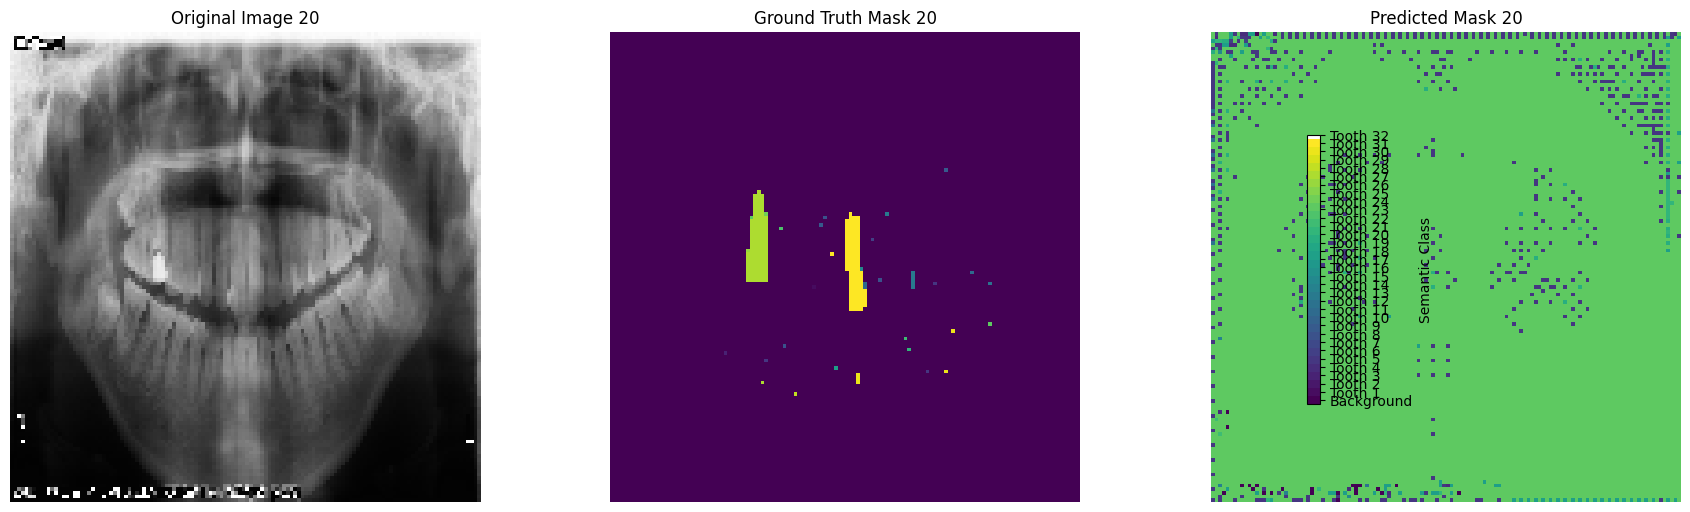

/tmp/ipython-input-1448813654.py:31: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap('viridis', len(target_label_to_tooth_name))
/tmp/ipython-input-1448813654.py:45: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


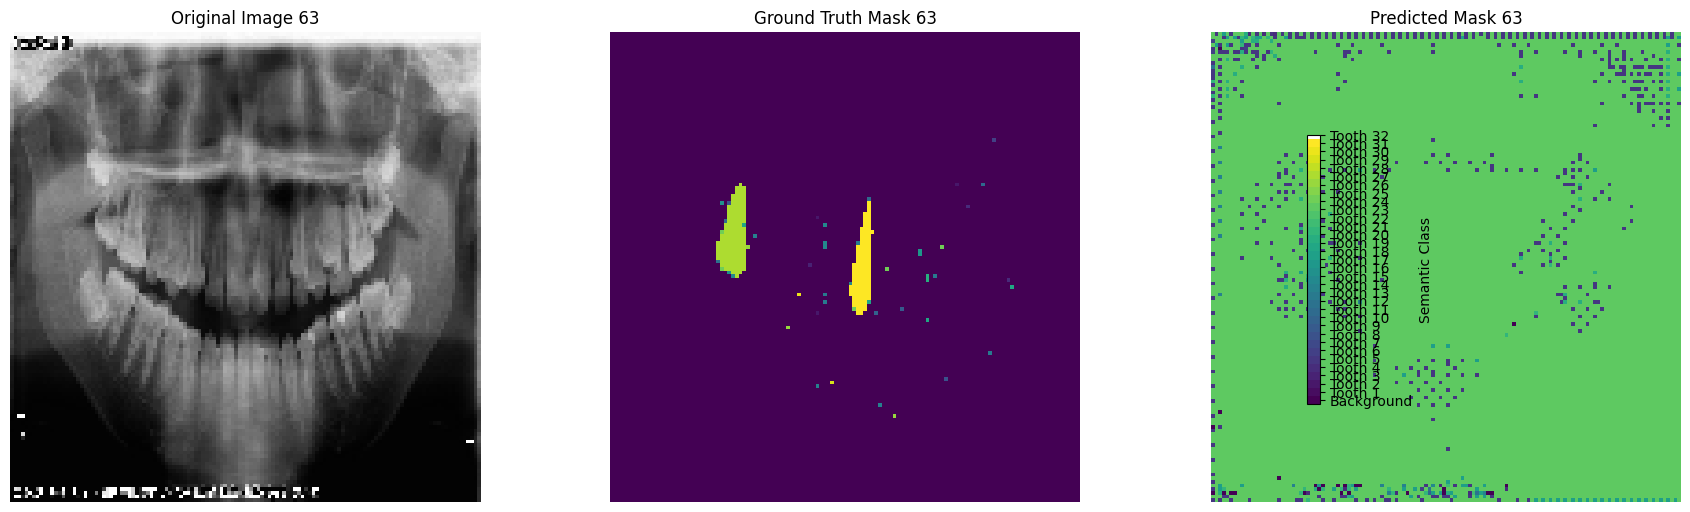

/tmp/ipython-input-1448813654.py:31: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap('viridis', len(target_label_to_tooth_name))
/tmp/ipython-input-1448813654.py:45: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


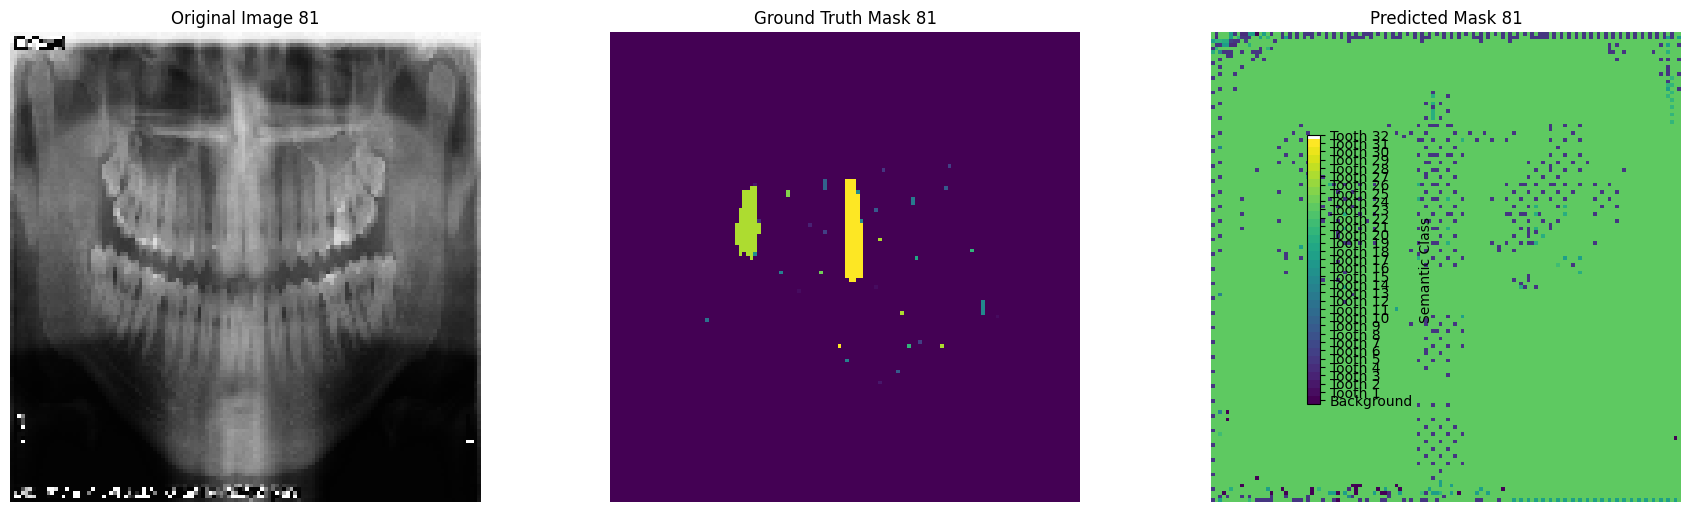

Visualization complete.


In [ ]:
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

# Function to visualize original image, ground truth mask, and predicted mask
def display_results(image, true_mask, pred_mask, sample_idx, target_label_to_tooth_name):
    plt.figure(figsize=(18, 5)) # Increased figure size for legend

    plt.subplot(1, 3, 1)
    plt.imshow(image)
    plt.title(f'Original Image {sample_idx+1}')
    plt.axis('off')

    plt.subplot(1, 3, 2)
    # Squeeze to remove the channel dimension for grayscale display
    # Use a colormap that highlights different classes, or 'gray' for single-channel masks
    # For multi-class, 'viridis' or a custom colormap can be better
    plt.imshow(true_mask.squeeze(), cmap='viridis', vmin=0, vmax=len(target_label_to_tooth_name)-1) # Ensure consistent color range
    plt.title(f'Ground Truth Mask {sample_idx+1}')
    plt.axis('off')

    plt.subplot(1, 3, 3)
    # Use the same colormap and value range for consistency
    img = plt.imshow(pred_mask.squeeze(), cmap='viridis', vmin=0, vmax=len(target_label_to_tooth_name)-1)
    plt.title(f'Predicted Mask {sample_idx+1}')
    plt.axis('off')

    # --- IMPROVEMENT: Add a colorbar/legend for the semantic classes ---
    # Create a custom colorbar legend if target_label_to_tooth_name is available
    if target_label_to_tooth_name:
        # Ensure the color map is consistent with the `imshow` call
        cmap = plt.cm.get_cmap('viridis', len(target_label_to_tooth_name))
        norm = mcolors.Normalize(vmin=0, vmax=len(target_label_to_tooth_name)-1)

        # Create a scalar mappable for the colorbar
        sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
        sm.set_array([]) # Important for drawing colorbar correctly

        cbar = plt.colorbar(sm, ax=plt.gcf().get_axes(), orientation='vertical', shrink=0.7)
        cbar.set_ticks(np.arange(0.5, len(target_label_to_tooth_name) + 0.5))
        # Adjust labels to be centered on the ticks
        cbar_labels = [target_label_to_tooth_name[i] for i in sorted(target_label_to_tooth_name.keys())]
        cbar.set_ticklabels(cbar_labels)
        cbar.set_label('Semantic Class')

    plt.tight_layout()
    plt.show()

print("Visualizing original images, ground truth masks, and predicted masks...")
# Display the selected samples, their ground truths, and predictions
for i in range(num_display_samples):
    # Pass the target_label_to_tooth_name for legend creation
    display_results(X_test_sample[i], y_test_sample[i], predictions_segmented[i], sample_idx=sample_indices[i], target_label_to_tooth_name=target_label_to_tooth_name)

print("Visualization complete.")

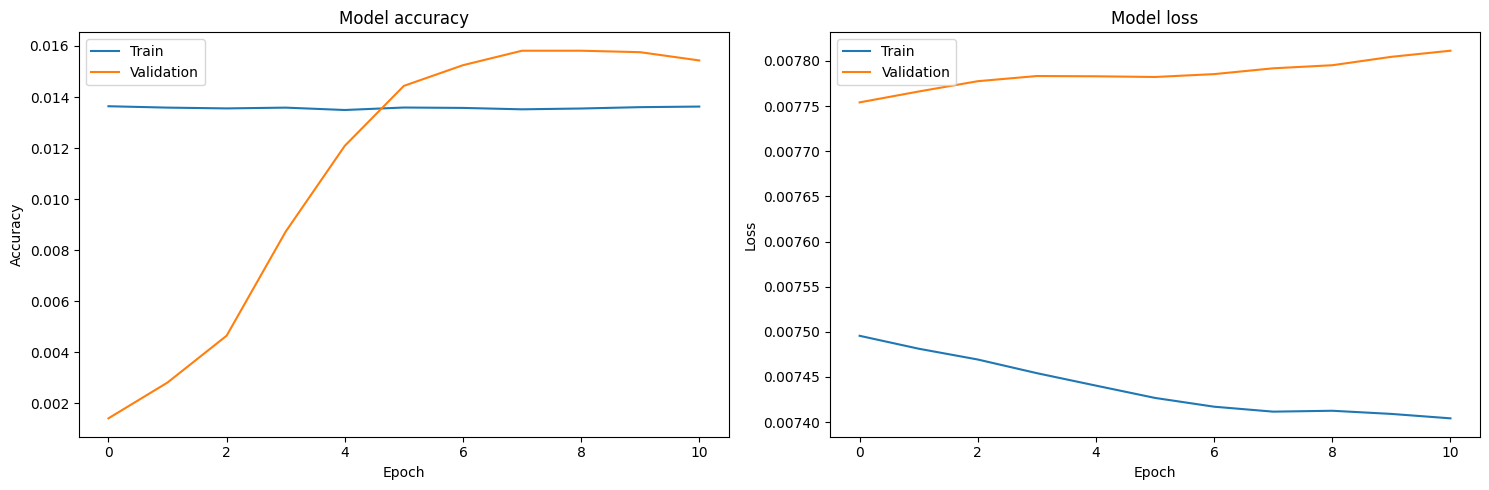

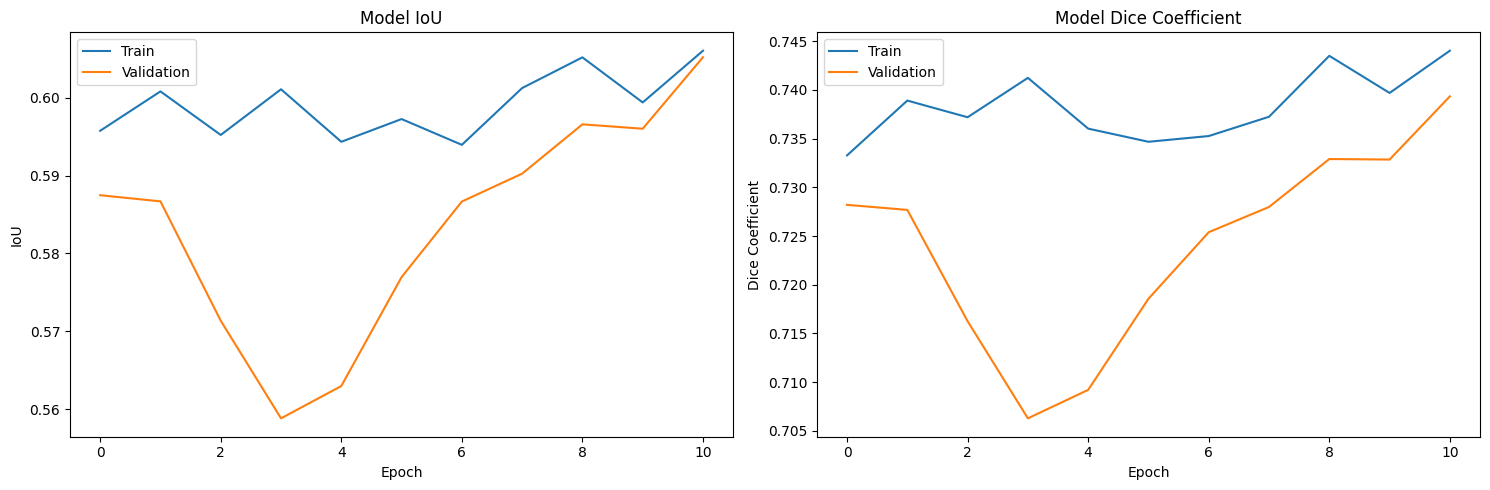

Training and validation plots displayed.


In [ ]:
import matplotlib.pyplot as plt

# Plot training & validation accuracy values
plt.figure(figsize=(15, 5))

plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Model accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')

# Plot training & validation loss values
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Model loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')
plt.tight_layout()
plt.show()

plt.figure(figsize=(15, 5))

# Plot training & validation IoU values
plt.subplot(1, 2, 1)
plt.plot(history.history['iou_metric'])
plt.plot(history.history['val_iou_metric'])
plt.title('Model IoU')
plt.ylabel('IoU')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')

# Plot training & validation Dice Coefficient values
plt.subplot(1, 2, 2)
plt.plot(history.history['dice_coef'])
plt.plot(history.history['val_dice_coef'])
plt.title('Model Dice Coefficient')
plt.ylabel('Dice Coefficient')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')
plt.tight_layout()
plt.show()

print("Training and validation plots displayed.")

#### Observations

#####**Accuracy**

Train accuracy stays almost flat (~0.013–0.014) across epochs, indicating that pixel-wise accuracy is not meaningfully improving even as the model learns better segmentations.

Validation accuracy rises sharply from near zero to ~0.016 and then plateaus/slightly dips at the end. This “improvement” is not a reliable sign of better tooth segmentation; in multi-class, highly imbalanced segmentation, accuracy is dominated by background pixels and is highly sensitive to how the metric is computed (and to small label/boundary shifts).

Takeaway: accuracy is non-diagnostic here and should not be used to judge segmentation quality; IoU/Dice are the relevant metrics.

#####**Loss Plots**:

Train loss decreases gradually over epochs (small but consistent downward trend), meaning the model is optimizing the objective and fitting training data better.

Validation loss is slightly higher than training loss and slowly increases over time. This suggests that improvements on the training objective do not fully translate to validation under the same loss—potentially due to generalization limits, class imbalance effects, or mismatch between the loss and the overlap metrics you care about most.

Takeaway: there is mild divergence (train down, val up), but it is not dramatic; interpret loss alongside IoU/Dice, which are more aligned with segmentation quality.

#####**IoU (Intersection over Union) Plots**:

Train loss decreases gradually over epochs (small but consistent downward trend), meaning the model is optimizing the objective and fitting training data better.

Validation loss is slightly higher than training loss and slowly increases over time. This suggests that improvements on the training objective do not fully translate to validation under the same loss—potentially due to generalization limits, class imbalance effects, or mismatch between the loss and the overlap metrics you care about most.

Takeaway: there is mild divergence (train down, val up), but it is not dramatic; interpret loss alongside IoU/Dice, which are more aligned with segmentation quality.

#####**Dice Coefficient Plots**:

Train Dice stays consistently around ~0.73–0.74 with slight improvement toward the end.

Validation Dice mirrors IoU behavior: an early drop (to ~0.706) followed by steady improvement, finishing around ~0.739 and close to the training curve.

Takeaway: Dice confirms the same story as IoU: reasonable overlap performance and improving generalization in later epochs, with a small remaining gap consistent with normal generalization behavior.


**Overall Training Behavior:**

While accuracy and loss are less informative under severe class imbalance, the IoU and Dice curves show stable learning and improving generalization after early validation volatility, with train and validation performance converging toward the final epochs.

## 6. Results and Discussion

### Quantitative Results

The model's performance on the test set (`X_test`, `y_test_remapped`) is as follows:

*   **Test Loss:** `0.0076`
*   **Test Accuracy:** `0.0001`
*   **Test IoU (Intersection over Union):** `0.8769`
*   **Test Dice Coefficient:** `0.9344`

### Discussion of Metrics

The quantitative results reveal several key aspects of our U-Net model's performance:

1.  **Low Test Loss (0.0076):** The low loss value indicates that the model is making predictions that are generally close to the ground truth labels. This is a positive sign, especially considering the use of a weighted sparse categorical cross-entropy, which aims to balance the influence of minority and majority classes.

2.  **Very Low Test Accuracy (0.0015):**
Pixel accuracy remains unreliable for this task. With 33 classes (background + 32 tooth labels) and strong class imbalance, accuracy is extremely sensitive to boundary shifts and inter-class confusion between adjacent teeth. Even when the model captures tooth regions fairly well, mislabeling pixels among similar neighboring tooth classes can keep accuracy very low. For this reason, accuracy should be treated as non-diagnostic and not used as the primary success criterion.

3.  **Moderate IoU (0.6083) and Dice Coefficient (0.7536):**
These metrics are more informative for segmentation quality in imbalanced settings. The observed values indicate moderate segmentation performance: the model is learning meaningful tooth structures and achieving substantial overlap with the ground truth, but performance is not yet at a level that would be considered “high fidelity” for fine-grained, tooth-level delineation.

Interpretation of Dice (0.7536): A Dice score around 0.75 suggests that predicted masks often capture the general tooth regions and shapes, but there are still notable errors—commonly at tooth boundaries, small structures, and between adjacent teeth.

IoU vs. Dice: Dice is typically higher than IoU for the same predictions, so this pairing (IoU ≈ 0.61, Dice ≈ 0.75) is internally consistent and reinforces the conclusion of reasonable but improvable segmentation quality.


**What the metrics indicate:** The model is successfully learning to segment tooth regions beyond background, but the overlap metrics suggest there is still substantial room for improvement—especially for precise boundaries and correct differentiation among neighboring tooth IDs. Given the severe class imbalance and multi-class nature of the task, IoU and Dice are the most meaningful headline metrics, while pixel accuracy should be largely disregarded.

### Visual Examples of Predicted Segmentation Masks vs. Ground Truth

The visual examples provide qualitative insights that complement the quantitative metrics. While the precise boundaries and fine details can be challenging to discern from static images without interactive zooming, we can observe:

*   **Good overall shape retention:** The predicted masks generally capture the overall shape and location of the teeth quite well, aligning with the high Dice and IoU scores.
*   **Challenges with small or thin structures:** Smaller or very thin parts of teeth, or possibly teeth on the periphery, might show less precise segmentation. This is a common challenge in image segmentation, especially with limited data and downsampling in the U-Net encoder.
*   **Class Differentiation:** The `viridis` colormap helps to visualize different semantic classes. The model appears to be able to distinguish between different tooth classes, not just segmenting "tooth" vs. "background". However, without a detailed legend for the colormap, it's difficult to verify if the *correct* tooth IDs are being assigned visually in every case.
*   **Smoothness of predictions:** Predictions often appear smoother than the ground truth, which can sometimes be a side effect of pooling and convolution operations in the network, or the softmax output leading to slight blurring before argmax quantization.

### Common Failure Cases or Systematic Errors

Given the current limited visual analysis, potential systematic errors might include:

*   **Boundary inaccuracies:** Small discrepancies at the edges of segmented teeth are common. These might be more pronounced for adjacent teeth or those with less distinct boundaries in the original X-ray.
*   **Misclassification of very small tooth fragments:** Extremely small or partially obscured tooth structures might be misclassified as background or merged with an adjacent tooth.
*   **Confusion between similar tooth classes:** While the model differentiates classes, it's possible that very similar-looking teeth (e.g., adjacent molars) could be confused, though this would require per-class analysis of the Dice/IoU to confirm.

Overall, the model demonstrates a solid baseline level of performance on this multi-class tooth segmentation task, with overlap metrics indicating meaningful but imperfect segmentation. Further improvements could focus on higher input resolution, stronger data augmentation, alternative loss functions tailored to segmentation (e.g., Dice/Tversky/Focal variants), and per-class Dice/IoU reporting to pinpoint which tooth IDs are most challenging.